# Klasifikacija proizvoda po nazivu
Cilj: na osnovu `Product Title` predvidjeti `Category Label`.

Faze: 1) ucitavanje i istrazivanje, 2) ciscenje, 3) inzenjering karakteristika, 4) poredjenje modela, 5) evaluacija finalnog modela.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from common import load_and_clean
sns.set_theme()

## 1. Ucitavanje i istrazivanje

In [2]:
raw = pd.read_csv('../data/products.csv')
print(raw.shape)
print(list(raw.columns))   # primijeti razmake/donje crte u nazivima kolona
raw.head()

(35311, 8)
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [3]:
raw.columns = [c.strip() for c in raw.columns]
print(raw.isna().sum())
print('Duplirani naslovi:', raw['Product Title'].duplicated().sum())
print(raw['Category Label'].value_counts())

product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64
Duplirani naslovi: 4450
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


**Zapazanja:**
- Nazivi kolona imaju vodece razmake i `_` (npr. `' Category Label'`, `'_Product Code'`).
- Prazne vrijednosti u `Product Title` (172) i `Category Label` (44).
- Nekonzistentne oznake kategorija: `fridge`, `CPU`, `Mobile Phone` su varijante `Fridges`, `CPUs`, `Mobile Phones`.
- Ostale kolone (Merchant ID, Views, Rating, Date) nemaju veze sa kategorijom, koristimo samo naslov.

## 2. Ciscenje
Sva logika je u `common.py` (`load_and_clean`): brisanje praznih, ujednacavanje kategorija, mala slova, brisanje duplikata.

(30826, 2) 10 kategorija


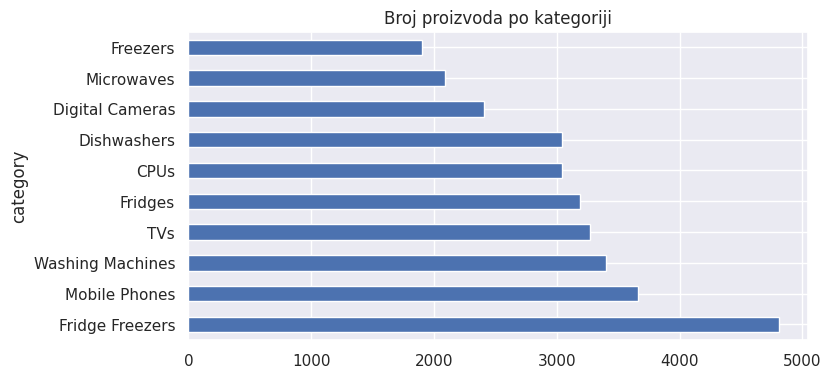

In [4]:
df = load_and_clean('../data/products.csv')
print(df.shape, df['category'].nunique(), 'kategorija')
df['category'].value_counts().plot.barh(figsize=(8,4)); plt.title('Broj proizvoda po kategoriji'); plt.show()

## 3. Inzenjering karakteristika
Probamo dodati meta-karakteristike naslova: broj rijeci, broj karaktera, ima li brojeva, udio cifara, najduza rijec, broj specijalnih znakova.

In [5]:
def meta_features(s):
    return pd.DataFrame({
        'n_words': s.str.split().str.len(),
        'n_chars': s.str.len(),
        'has_digit': s.str.contains(r'\d').astype(int),
        'digit_ratio': s.apply(lambda t: sum(c.isdigit() for c in t)/max(len(t),1)),
        'max_word_len': s.apply(lambda t: max((len(w) for w in t.split()), default=0)),
        'n_special': s.str.count(r'[^a-z0-9\s]'),
    })
meta = meta_features(df['title']); meta['category'] = df['category']
meta.groupby('category').mean().round(2)

,n_words,n_chars,has_digit,digit_ratio,max_word_len,n_special
category,,,,,,
CPUs,12.85,68.64,1.00,0.19,9.42,1.03
Digital Cameras,9.52,49.31,0.98,0.12,7.75,0.49
Dishwashers,6.79,50.16,0.96,0.12,11.06,0.06
Freezers,7.19,48.59,0.96,0.12,10.42,0.09
Fridge Freezers,8.20,55.12,0.97,0.11,10.29,0.23
Fridges,7.53,48.54,0.97,0.12,10.02,0.07
Microwaves,7.62,51.66,0.96,0.13,10.30,0.10
Mobile Phones,8.42,45.60,0.92,0.11,7.98,0.36
TVs,10.10,53.99,0.99,0.19,10.18,0.24


Prosjeci se razlikuju od kategorije do kategorije, pa ima smisla provjeriti poboljsavaju li model. Provjera je u sekciji 4.

## 4. Poredjenje modela

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['title'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

def tfidf():
    return FeatureUnion([
        ('word', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), sublinear_tf=True, min_df=2)),
    ])

models = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'LinearSVC': LinearSVC(class_weight='balanced'),
}
results = {}
for name, clf in models.items():
    p = Pipeline([('tfidf', tfidf()), ('clf', clf)]).fit(X_train, y_train)
    results[name] = accuracy_score(y_test, p.predict(X_test))
    print(f'{name:20s} {results[name]:.4f}')

MultinomialNB        0.9492


LogisticRegression   0.9818


RandomForest         0.9804


LinearSVC            0.9906


In [7]:
# Eksperiment: TF-IDF + meta karakteristike (LinearSVC)
vec = tfidf().fit(X_train)
sc = StandardScaler().fit(meta_features(X_train))
def stack(s): return hstack([vec.transform(s), csr_matrix(sc.transform(meta_features(s)))]).tocsr()
clf = LinearSVC(class_weight='balanced').fit(stack(X_train), y_train)
acc_meta = accuracy_score(y_test, clf.predict(stack(X_test)))
print(f'TF-IDF + meta karakteristike: {acc_meta:.4f}  (bez meta: {results["LinearSVC"]:.4f})')

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


TF-IDF + meta karakteristike: 0.9908  (bez meta: 0.9906)


**Zakljucak:** meta karakteristike ne daju znacajno poboljsanje preko TF-IDF-a (razlika je u granicama sumnje), pa ih ne koristimo u finalnom modelu. Odabran je **LinearSVC + TF-IDF (rijeci i karakteri)**: najtacniji ili medju najtacnijim, brz za treniranje i predikciju, i jednostavan za koristenje.

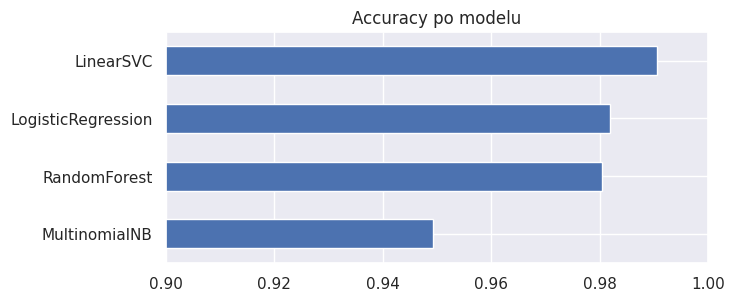

In [8]:
pd.Series(results).sort_values().plot.barh(figsize=(7,3), xlim=(0.9,1.0)); plt.title('Accuracy po modelu'); plt.show()

## 5. Evaluacija finalnog modela

In [9]:
final = Pipeline([('tfidf', tfidf()), ('clf', LinearSVC(class_weight='balanced'))]).fit(X_train, y_train)
pred = final.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

Accuracy: 0.9906
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       0.99      1.00      1.00       608
        Freezers       0.99      0.98      0.99       381
 Fridge Freezers       0.98      0.99      0.99       962
         Fridges       0.98      0.97      0.97       638
      Microwaves       0.99      0.99      0.99       419
   Mobile Phones       1.00      0.99      1.00       732
             TVs       1.00      1.00      1.00       655
Washing Machines       0.99      0.99      0.99       681

        accuracy                           0.99      6166
       macro avg       0.99      0.99      0.99      6166
    weighted avg       0.99      0.99      0.99      6166



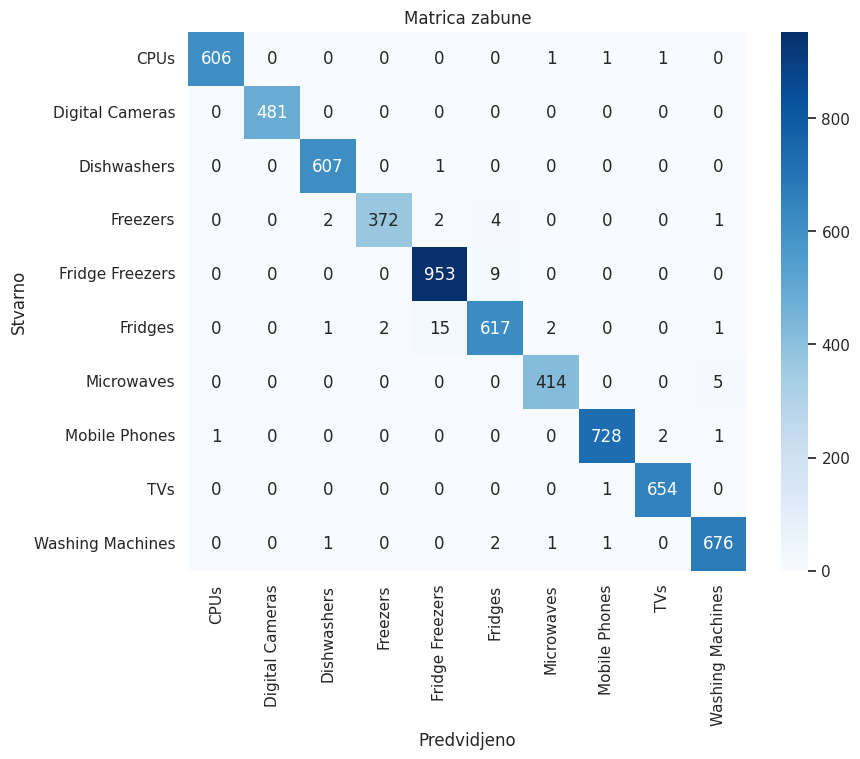

In [10]:
labels = sorted(df['category'].unique())
cm = confusion_matrix(y_test, pred, labels=labels)
plt.figure(figsize=(9,7)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predvidjeno'); plt.ylabel('Stvarno'); plt.title('Matrica zabune'); plt.show()

Najvise gresaka je izmedju **Fridges / Fridge Freezers / Freezers**, sto je i ocekivano jer su to vrlo slicni proizvodi sa slicnim nazivima.

## 6. Test na primjerima iz zadatka

In [11]:
tests = ['iphone 7 32gb gold','olympus e m10 mark iii geh use silber','kenwood k20mss15 solo',
         'bosch wap28390gb 8kg 1400 spin','bosch serie 4 kgv39vl31g','smeg sbs8004po']
for t in tests: print(f'{t:42s} -> {final.predict([t])[0]}')

iphone 7 32gb gold                         -> Mobile Phones
olympus e m10 mark iii geh use silber      -> Digital Cameras
kenwood k20mss15 solo                      -> Microwaves
bosch wap28390gb 8kg 1400 spin             -> Washing Machines
bosch serie 4 kgv39vl31g                   -> Fridge Freezers
smeg sbs8004po                             -> Dishwashers


Napomena: ovdje se koristi model treniran samo na train skupu; rubni slucajevi poput `smeg sbs8004po` (kratak naziv bez opisa) mogu se razlikovati od finalnog modela treniranog na cijelom skupu (`models/model.pkl`), koji ga svrstava u Fridge Freezers.

Finalni model za isporuku (treniran na cijelom skupu) pravi `train_model.py` i cuva ga u `models/model.pkl`.